In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import afterglowpy as grb
import random

from astropy.cosmology import Planck18 as cosmo
from tqdm.notebook import tqdm

In [2]:
import skysurvey
import sncosmo

from skysurvey.target.core import Transient
from skysurvey.tools import random_radec

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

In [5]:
! pip show skysurvey

Name: skysurvey
Version: 0.16.6
Summary: Simulating Transient in the sky and how to observe them
Home-page: https://github.com/MickaelRigault/skysurvey
Author: Mickael Rigault
Author-email: m.rigault@ipnl.in2p3.fr
License: Apache Software License
Location: /home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages
Requires: astropy, extinction, geopandas, healpy, importlib-resources, modeldag, numpy, pandas, scipy, shapely, sncosmo, ztffields
Required-by: 


## Open ZTF observation logs

In [6]:
data = pd.read_parquet("/home/masson/orphans/data/ztf_obsfile_maglimcat.parquet")

In [7]:
data = data.rename(columns={'expMJD': 'mjd', 'filter': 'band', 'fieldID': 'fieldid'})
data['skynoise'] = np.random.normal(size=len(data), loc=50, scale=20)

In [8]:
data

,mjd,band,fieldid,fieldRA,fieldDec,rcid,maglimcat,zp,gain,expid,infobits,skynoise
0,58288.171875,ztfi,375,3.787257,-0.171915,16,19.650887,25.644886,6.2,53417042,0,66.165404
1,58288.171875,ztfi,375,3.787257,-0.171915,17,19.612961,25.651960,6.2,53417042,0,21.316444
2,58288.171875,ztfi,375,3.787257,-0.171915,18,19.686562,25.683561,6.2,53417042,0,67.569225
3,58288.171875,ztfi,375,3.787257,-0.171915,19,19.632156,25.650158,6.2,53417042,0,44.706395
4,58288.171875,ztfi,375,3.787257,-0.171915,20,19.573307,25.693308,6.2,53417042,0,37.161428
...,...,...,...,...,...,...,...,...,...,...,...,...
47184470,59822.519531,ztfr,252,0.923487,-0.423242,35,20.596474,28.828974,6.3,206851832,37748737,42.032756
47184471,59822.519531,ztfr,252,0.923487,-0.423242,34,20.711779,28.898779,6.2,206851832,33554433,26.250381
47184472,59822.519531,ztfr,252,0.923487,-0.423242,33,20.669249,28.793249,6.5,206851832,33554433,49.500533
47184473,59822.519531,ztfr,252,0.923487,-0.423242,31,20.614706,28.737206,6.3,206851832,33554433,34.429202


In [9]:
ztf = skysurvey.ZTF.from_pointings(data)

In [10]:
# take events that happens during the time ZTF was operating
tstart, tstop = ztf.get_timerange()

## Create an orphan `Transient`

In [11]:
# load orphan afterglow configurations that are observable by Rubin LSST
orphan_configs = pd.read_pickle('../data/pseudo_obs/features_po_mvsr_sbat4_5_pts_all_2602.pkl')

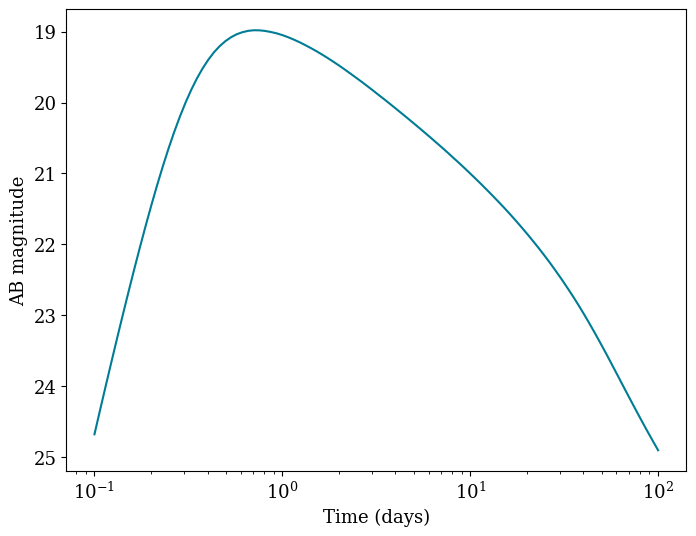

In [12]:
t = np.geomspace(0.1, 100., 100)
nu = 482703137570394.2   # ~ r-band frequency
#nu = 299792458 / (3600.*1e-10)

# choose a nice orphan
Z = orphan_configs.iloc[4]['config']

fnu = grb.fluxDensity(t*grb.day2sec, nu, **Z)
mag_obs = -2.5 * np.log10(fnu * 1.0e-26) - 48.6

plt.figure(figsize=(8, 6))
plt.rcParams.update({'font.size': 13})

plt.plot(t, mag_obs, color='#007c95')
plt.ylabel('AB magnitude')
plt.gca().invert_yaxis()

plt.xlabel('Time (days)')
plt.xscale('log')

plt.show()

In [13]:
def get_grb_params():
    """ Get an orphan parameter configuration among orphan that were observable by Rubin LSST
    
    Returns
    -------
    grb_params : dictionary
        Model parameters used to compute GRB afterglow light curves
    """
    
    return orphan_configs.iloc[4]['config']


def get_flux(grb_params):
    """ Compute the spectral flux density for ZTF frequency coverage. 
    The flux is computed by `afterglowpy` (Ryan et al. 2020).
    
    Parameters
    ----------
    grb_params : dictionary
        Model parameters used to compute GRB afterglow light curves
        
    Returns
    -------
    phase : numpy.ndarray
        Phases in days.
    wave : numpy.ndarray
        Wavelengths in Angstroms.
    flux : numpy.ndarray
        Model spectral flux density in arbitrary units.
    """ 
    
    phase = np.linspace(0., 300., 100)  # time in days
    wave = np.linspace(3000, 9000, 100)   # wavelength in Angstrom
    nu = 299792458 / (wave*1e-10)
    
    flux = []
    for p in phase:
        if p == 0.:
            flux.append([10**-28] * len(phase))
        else:
            t = p * np.ones(nu.shape) * grb.day2sec
            mJys = grb.fluxDensity(t, nu, **grb_params)
            Jys = 1e-3 * mJys

            # convert to erg/s/cm^2/A
            flux.append(Jys * 1e-23 * 2.99792458e18 / (wave**2))   # 2.99792458e18 is the light speed in A/s
      
    return phase, wave, flux


def get_orphan_model():
    """ """ 
    
    grb_params = get_grb_params()
    phase, wave, flux = get_flux(grb_params)
    
    orphan_source = sncosmo.TimeSeriesSource(phase, wave, np.array(flux), name='orphan')
    model = sncosmo.Model(orphan_source)

    return model

In [14]:
grb_params = get_grb_params()
phase, wave, flux = get_flux(grb_params)

mag_obs = -2.5 * np.log10(np.array(flux) / (2.99792458e18 / (wave**2))) - 48.6
mag_abs = mag_obs - 5 * np.log10(grb_params['d_L']/3.0857e18) + 5

In [15]:
# =============== #
#                 #
#  Orphan         #
#                 #
# =============== #

_ORPHAN_MODEL = get_orphan_model()
class Orphan(Transient):

    _KIND = "orphan"
    _TEMPLATE = _ORPHAN_MODEL
    _RATE = 10 # event per Gyr**3
    _MODEL = dict( # when
                   t0 = {"func": np.random.uniform,
                         "kwargs": {"low":tstart, "high":tstop}
                        },
                         
                   # what     
                   magabs = {"func": np.random.normal,
                             "kwargs": {"loc": np.min(mag_abs[:,53]), "scale": 0.}
                            },
                             
                   magobs = {"func": "magabs_to_magobs",
                             "kwargs": {"z":grb_params['z'], "magabs": "@magabs"}
                            },
                                       
                   amplitude = {"func": "magobs_to_amplitude",
                                "kwargs": {"magobs": "@magobs"}
                            },

                   # where
                   radec = {"func": random_radec,
                            "kwargs": {},
                            "as": ["ra","dec"]
                           },
                   )

In [16]:
orphan = Orphan()

oa_transient = Orphan.from_draw(size=10)
oa_transient.data

,t0,magabs,ra,dec,magobs,amplitude,template
0,59402.789062,-18.207945,159.017487,28.693357,19.831898,1.467153,orphan
1,59054.046875,-18.207945,355.936249,-47.660217,19.831898,1.467153,orphan
2,59317.082031,-18.207945,4.759934,-24.517887,19.831898,1.467153,orphan
3,59630.253906,-18.207945,148.986938,38.233841,19.831898,1.467153,orphan
4,58346.554688,-18.207945,208.125381,11.979158,19.831898,1.467153,orphan
5,58677.410156,-18.207945,14.652331,-19.923496,19.831898,1.467153,orphan
6,58602.589844,-18.207945,307.418213,2.881205,19.831898,1.467153,orphan
7,59045.851562,-18.207945,350.797455,65.204407,19.831898,1.467153,orphan
8,58878.203125,-18.207945,34.306122,-7.917656,19.831898,1.467153,orphan
9,59013.230469,-18.207945,223.258575,21.180450,19.831898,1.467153,orphan


(25.0, 15.0)

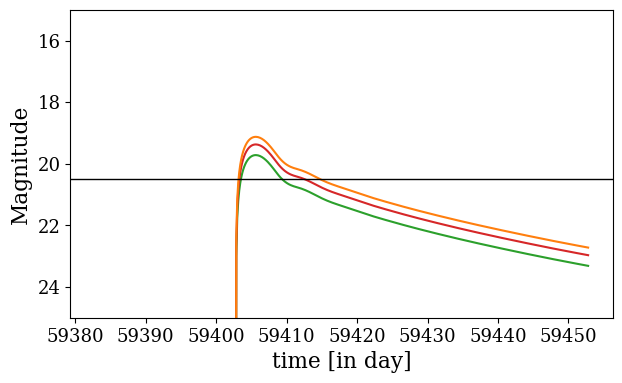

In [17]:
# theoretical light curve of our transient
_ = oa_transient.show_lightcurve(["ztfg","ztfr","ztfi"], index=0, 
                                     in_mag=True, format_time=False)

plt.axhline(y=20.5, lw=1, c='k')
plt.ylim(25, 15)

## Simulate observations of our Transient with ZTF

In [18]:
dset = skysurvey.DataSet.from_targets_and_survey(oa_transient, ztf)
dset.data

fieldid  rcid          time  band       flux    fluxerr  \
index                                                                     
2     853631        245    16  58313.480469  ztfg  23.817580  43.387309   
      1049706       245    16  58320.460938  ztfg  -7.586237  47.131214   
      1052371       245    16  58320.480469  ztfr -34.800124  44.808013   
      1174418       245    16  58323.480469  ztfr  46.803420  47.481537   
      1300534       245    16  58326.460938  ztfg  -6.503835  61.860825   
...                 ...   ...           ...   ...        ...        ...   
7     46804286     1709    33  59811.449219  ztfi  -6.420305  51.429541   
      46938399     1709    33  59815.371094  ztfi  -4.326825  16.863310   
      47076729     1709    33  59819.355469  ztfi -12.353176  94.736769   
      47126746     1709    33  59821.347656  ztfi  52.217220  52.983327   
      47168256     1709    33  59822.371094  ztfi  -1.975011  47.914028   

                       zp zpsys  
index                            
2     853631    25.808598    ab  
      1049706   25.592997    ab  
      1052371   26.069078    ab  
      1174418   26.098038    ab  
      1300534   24.854919    ab  
...                   ...   ...  
7     46804286  25.745365    ab  
      46938399  25.749887    ab  
      47076729  25.803263    ab  
      47126746  25.787926    ab  
      47168256  25.784575    ab  

[7575 rows x 8 columns]

In [19]:
dset.get_ndetection()

index
0    14
3     6
5     3
6     2
7    14
9     5
dtype: int64

**1. ZTF limiting magnitude**

Median five-sigma model limiting magnitudes are (see *The Zwicky Transient Facility: System Overview, Performance, and First Results* from Bellm et al., 2018):
- g-band: 20.8, 
- r-band: 20.6, 
- i-band: 19.9.


**2. Zero-point**

The **zero point (zp)** of an instrument, by definition, is the magnitude of an object that produces one count (or data number, $DN$) per second. The magnitude of an arbitrary object producing $DN$ counts in an observation of length $EXPTIME$ is therefore:

$$ m = -2.5 \times \log_{10}\left( \frac{DN}{EXPTIME} \right) + ZEROPOINT $$

It is the setting of the zeropoint, then, which determines the connection between observed counts and a standard photometric system, and in turn between counts and astrophysically interesting measurements such as the flux incident on the telescope.

In `skysurvey`, the flux is standardised to a zero-point $zp = 25$:

$$ F_{standardised} = F_{obs} \times 10^{-(zp_{obs} - zp) / 2.5} $$

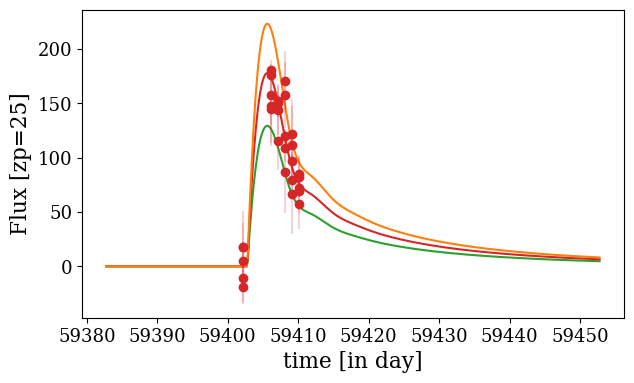

In [20]:
if len(dset.get_ndetection()) > 0:
    dset.show_target_lightcurve(index=0, phase_window=[-2, 30], format_time=False, bands=['ztfg', 'ztfr', 'ztfi'])

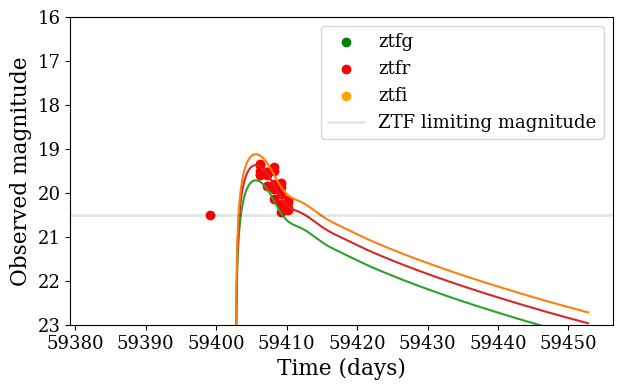

In [21]:
n = 0

ztf_bands = ['ztfg', 'ztfr', 'ztfi']
ztf_freq = [620752578941919.5, 463805775285244.6, 379313672969741.44]   # ZTF effective band frequencies
band_colors = ['g', 'r', 'orange']

# compute the theoretical light curve in AB mag
oa_transient.show_lightcurve(["ztfg","ztfr","ztfi"], index=n, in_mag=True, format_time=False)

for nu, b, c in zip(ztf_freq, ztf_bands, band_colors):
        
    # keep only the times, flux and zero-points 5 days before and 50 days after the beginning of the light curve
    tmin = oa_transient.data.iloc[n]['t0']-5.
    tmax = oa_transient.data.iloc[n]['t0']+50.
    
    time_obs = dset.data.loc[(dset.data['time'] >= tmin) & (dset.data['time'] <= tmax) & (dset.data['band'] == b), 
                             'time']
    flux_obs = dset.data.loc[(dset.data['time'] >= tmin) & (dset.data['time'] <= tmax) & (dset.data['band'] == b),
                             'flux']
    zp_obs = dset.data.loc[(dset.data['time'] >= tmin) & (dset.data['time'] <= tmax) & (dset.data['band'] == b),
                             'zp']
    
    # convert from observed flux to magnitude using the zero-point value of the observation
    mag_obs = -2.5 * np.log10(flux_obs) + zp_obs

    plt.scatter(time_obs[mag_obs<20.5], mag_obs[mag_obs<20.5], color=c, label=b)
    
plt.axhline(y=20.5, color='k', alpha=0.1, lw=2, label='ZTF limiting magnitude')

plt.xlabel('Time (days)')
plt.ylabel('Observed magnitude')
plt.gca().invert_yaxis()
plt.ylim(23, 16)
plt.legend()

plt.show()

## Test over several orphan afterglows

In [22]:
 def get_grb_params():
    """ Get an orphan parameter configuration among orphan that were observable by Rubin LSST
    
    Returns
    -------
    grb_params : dictionary
        Model parameters used to compute GRB afterglow light curves
    """
    
    return orphan_configs.iloc[i]['config']


def get_flux(grb_params):
    """ Compute the spectral flux density for ZTF frequency coverage. 
    The flux is computed by `afterglowpy` (Ryan et al. 2020).
    
    Parameters
    ----------
    grb_params : dictionary
        Model parameters used to compute GRB afterglow light curves
        
    Returns
    -------
    phase : numpy.ndarray
        Phases in days.
    wave : numpy.ndarray
        Wavelengths in Angstroms.
    flux : numpy.ndarray
        Model spectral flux density in arbitrary units.
    """ 
    
    phase = np.linspace(0., 100., 100)  # time in days
    wave = np.linspace(3000, 9000, 100)   # wavelength in Angstrom
    nu = 299792458 / (wave*1e-10)
    
    flux = []
    for p in phase:
        if p == 0.:
            flux.append([10**-28] * len(phase))
        else:
            t = p * np.ones(nu.shape) * grb.day2sec
            mJys = grb.fluxDensity(t, nu, **grb_params)
            Jys = 1e-3 * mJys

            # convert to erg/s/cm^2/A
            flux.append(Jys * 1e-23 * 2.99792458e18 / (wave**2))   # 2.99792458e18 is the light speed in A/s
      
    return phase, wave, flux


def get_orphan_model():
    """ """ 
    
    grb_params = get_grb_params()
    phase, wave, flux = get_flux(grb_params)
    
    orphan_source = sncosmo.TimeSeriesSource(phase, wave, np.array(flux), name='orphan')
    model = sncosmo.Model(orphan_source)

    return model

In [23]:
def show_orphan_light_curve(transient_data, dset_data):
    
    ztf_bands = ['ztfg', 'ztfr', 'ztfi']
    ztf_freq = [620752578941919.5, 463805775285244.6, 379313672969741.44]   # ZTF effective band frequencies
    band_colors = ['g', 'r', 'orange']

    # compute the theoretical light curve in AB mag
    oa_transient.show_lightcurve(["ztfg","ztfr","ztfi"], index=0, in_mag=True, format_time=False)

    for nu, b, c in zip(ztf_freq, ztf_bands, band_colors):

        # keep only the times, flux and zero-points 5 days before and 50 days after the beginning of the light curve
        tmin = transient_data.iloc[0]['t0']-5.
        tmax = transient_data.iloc[0]['t0']+50.

        time_obs = dset_data.loc[(dset_data['time'] >= tmin) & (dset_data['time'] <= tmax) & (dset_data['band'] == b), 
                                 'time']
        flux_obs = dset_data.loc[(dset_data['time'] >= tmin) & (dset_data['time'] <= tmax) & (dset_data['band'] == b),
                                 'flux']
        zp_obs = dset_data.loc[(dset_data['time'] >= tmin) & (dset_data['time'] <= tmax) & (dset_data['band'] == b),
                                 'zp']

        # convert from observed flux to magnitude using the zero-point value of the observation
        mag_obs = -2.5 * np.log10(flux_obs) + zp_obs

        plt.scatter(time_obs, mag_obs, color=c, label=b)
        
    plt.axhline(y=20.5, color='k', alpha=0.1, lw=2, label='ZTF limiting magnitude')

    plt.xlabel('Time (days)')
    plt.ylabel('Observed magnitude')
    plt.gca().invert_yaxis()
    plt.ylim(23, 15)
    plt.legend()

    plt.show()

Orphan n°0: minimal magnitude is 20.486757909845487
Try n°1: not detected
Try n°2: not detected
Try n°3: not detected
Try n°4: not detected
Try n°5: not detected
Orphan n°1: minimal magnitude is 18.32662512099312
Try n°1: not detected


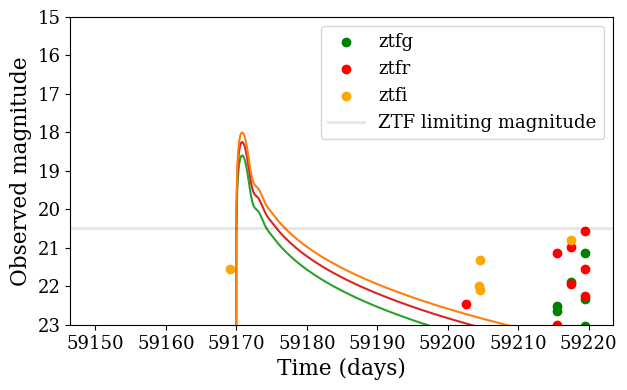

Orphan n°2: minimal magnitude is 19.920845991667782
Try n°1: not detected
Try n°2: not detected
Try n°3: not detected
Try n°4: not detected
Try n°5: not detected
Orphan n°3: minimal magnitude is 22.892626677331144
Too faint to be observed
Orphan n°4: minimal magnitude is 18.610394862604814


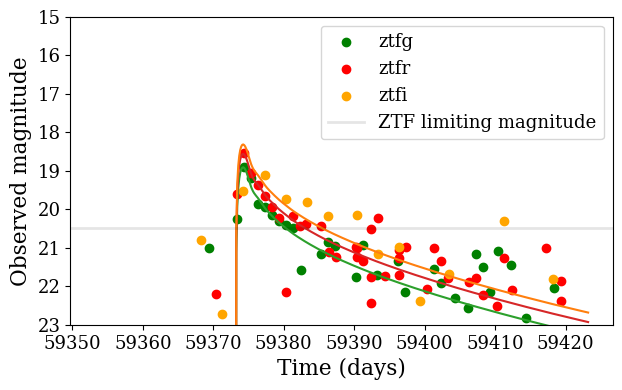

Orphan n°5: minimal magnitude is 18.49542127421929
Try n°1: not detected
Try n°2: not detected
Try n°3: not detected
Try n°4: not detected
Try n°5: not detected
Orphan n°6: minimal magnitude is 18.03976867819687


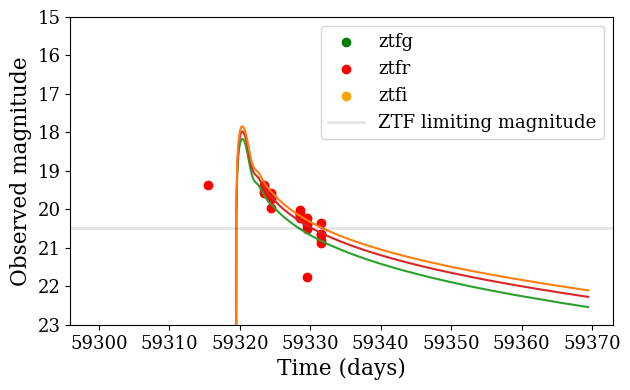

Orphan n°7: minimal magnitude is 20.19094891401334
Try n°1: not observed
Try n°2: not observed
Try n°3: not observed
Try n°4: not observed
Try n°5: not observed
Orphan n°8: minimal magnitude is 17.978921092217952


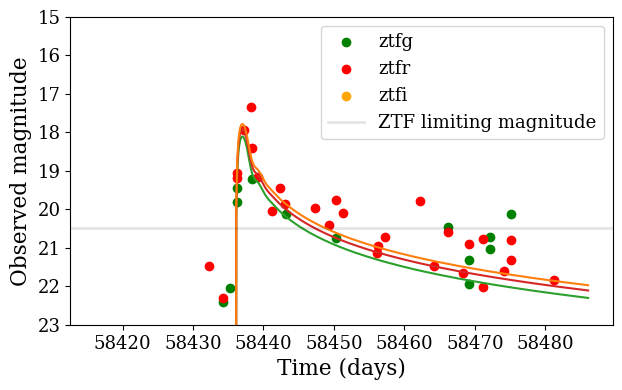

Orphan n°9: minimal magnitude is 15.595197548718382


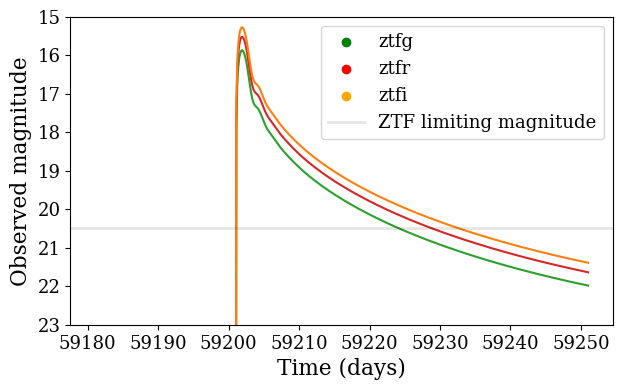

In [24]:
for i in range(10):

    grb_params = get_grb_params()
    phase, wave, flux = get_flux(grb_params)

    mag_obs = -2.5 * np.log10(np.array(flux) / (2.99792458e18 / (wave**2))) - 48.6

    print(f'Orphan n°{i}: minimal magnitude is {np.min(mag_obs)}')
    
    if np.min(mag_obs) < 20.5:
        mag_abs = mag_obs - 5 * np.log10(grb_params['d_L']/3.0857e18) + 5


        # =============== #
        #                 #
        #  Orphan         #
        #                 #
        # =============== #

        _ORPHAN_MODEL = get_orphan_model()
        class Orphan(Transient):

            _KIND = "orphan"
            _TEMPLATE = _ORPHAN_MODEL
            _RATE = 10 # event per Gyr**3
            _MODEL = dict( # when
                           t0 = {"func": np.random.uniform,
                                 "kwargs": {"low":tstart, "high":tstop}
                                },

                           # what     
                           magabs = {"func": np.random.normal,
                                     "kwargs": {"loc": np.min(mag_abs[:,53]), "scale": 0.}
                                    },

                           magobs = {"func": "magabs_to_magobs",
                                     "kwargs": {"z":grb_params['z'], "magabs": "@magabs"}
                                    },

                           amplitude = {"func": "magobs_to_amplitude",
                                        "kwargs": {"magobs": "@magobs"}
                                    },

                           # where
                           radec = {"func": random_radec,
                                    "kwargs": {},
                                    "as": ["ra","dec"]
                                   },
                           )

        orphan = Orphan()

        oa_transient = Orphan.from_draw(size=1)
        oa_transient.data
        
        n_try=0
        observed=False
        
        while n_try <= 4 and observed == False:

            try:
                dset = skysurvey.DataSet.from_targets_and_survey(oa_transient, ztf)
                if len(dset.get_ndetection()) > 0:
                    #dset.show_target_lightcurve(index=0, phase_window=[-5, 50], format_time=False, 
                                                #bands=['ztfg', 'ztfr', 'ztfi'])
                    show_orphan_light_curve(oa_transient.data, dset.data)
                    observed = True
                else:
                    n_try+=1
                    print(f'Try n°{n_try}: not detected')

            except:
                n_try+=1
                print(f"Try n°{n_try}: not observed")
            
    else:
        print("Too faint to be observed")
